# Statistical Inference and Hypothesis Testing

This notebook follows the Week 6 requirements from the Data Science Internship Program.

## Learning Goals

- Understand confidence intervals and margin of error.
- Understand the basic idea of hypothesis testing.
- Understand what a p-value means.
- Learn how simple A/B testing works.
- Apply a t-test to real data.
- Apply a chi-square test to real data.
- Interpret statistical test results in plain language.

A short notebook applying hypothesis testing to real data, with a plain-language explanation of the results.

## 1. Dataset

For this week's statistical analysis, we will use the cleaned Titanic dataset from Week 3.

The Titanic dataset contains information about passengers, including:

- Passenger class
- Sex
- Age
- Fare
- Survival status
- Family-related variables

The dataset is useful for hypothesis testing because it contains both numerical and categorical variables.


### importaing  libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# locating the path of the file 
file_path = "../Week_05_EDA_Visualization/data/titanic_clean.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (891, 16)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Is_Alone,Fare_Per_Person,Class_Name
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,2,False,3.62500,Third Class
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,False,35.64165,First Class
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,1,True,7.92500,Third Class
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,False,26.55000,First Class
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,1,True,8.05000,Third Class


## 2. Dataset Inspection

Before performing statistical tests, the dataset should be inspected to understand its structure and confirm that the required variables are available.

In [4]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (891, 16)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family_Size', 'Is_Alone', 'Fare_Per_Person', 'Class_Name']

Missing values:
PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin              0
Embarked           0
Family_Size        0
Is_Alone           0
Fare_Per_Person    0
Class_Name         0
dtype: int64

Duplicate rows: 0


## 3. Statistical Inference

Statistical inference uses sample data to learn about a larger population.
Instead of only describing the data we have, statistical inference helps us determine whether an observed pattern is likely to represent a real relationship or could have occurred by chance.
Two important ideas are:

- Confidence intervals
- Hypothesis testing

### Confidence Interval

A confidence interval gives a range of plausible values for a population parameter based on sample data. For example, a 95% confidence interval gives a range calculated using a method that would contain the true population parameter in about 95% of repeated samples under the assumptions of that method. A confidence interval is therefore more informative than reporting only a single sample estimate.
    
### Margin of Error

The margin of error describes how far the confidence interval extends from the sample estimate. A smaller margin of error generally indicates a more precise estimate.

In [5]:
ages = df["Age"].dropna()

mean_age = ages.mean()
standard_error = stats.sem(ages)

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(ages) - 1,
    loc=mean_age,
    scale=standard_error
)

print("Mean age:", round(mean_age, 2))
print("95% confidence interval:", 
      (round(confidence_interval[0], 2), 
       round(confidence_interval[1], 2)))

Mean age: 29.36
95% confidence interval: (np.float64(28.51), np.float64(30.22))


### Interpretation

The calculated confidence interval provides a range of plausible values for the population mean age based on the Titanic sample. The interval should not be interpreted as saying that 95% of individual passenger ages fall inside this range. It describes uncertainty around the estimated population mean.

## 4. Hypothesis Testing

Hypothesis testing provides a structured way to investigate a claim about data.
A hypothesis test generally contains two hypotheses:

### Null Hypothesis (H₀)

The null hypothesis represents the assumption that there is no meaningful difference or association.

### Alternative Hypothesis (H₁)

The alternative hypothesis represents the possibility that a difference or association exists.
The test produces a p-value that helps us evaluate how compatible the observed data are with the null hypothesis.

### Understanding the p-value

The p-value measures how unusual the observed result would be, or something more extreme, if the null hypothesis were true.

We use a significance level of 0.05.

### Decision Rule

- If **p-value < 0.05**, reject the null hypothesis.
- If **p-value >= 0.05**, do not reject the null hypothesis.

A p-value is **not** the probability that the null hypothesis is true.

In [6]:
alpha = 0.05

print("Significance level:", alpha)

print("\nDecision rule:")
print("If p-value < 0.05 → Reject the null hypothesis.")
print("If p-value >= 0.05 → Do not reject the null hypothesis.")

Significance level: 0.05

Decision rule:
If p-value < 0.05 → Reject the null hypothesis.
If p-value >= 0.05 → Do not reject the null hypothesis.


### Simple Hypothesis Testing Example

Suppose a statistical test produces a p-value of 0.03.

Because 0.03 is less than 0.05, we reject the null hypothesis.

This means that the result provides statistically significant evidence against the null hypothesis.

If the p-value were 0.20, we would not reject the null hypothesis because 0.20 is greater than 0.05.

In [7]:
example_p_value = 0.03

if example_p_value < alpha:
    print("P-value:", example_p_value)
    print("Decision: Reject the null hypothesis.")
    print("Result: Statistically significant at the 0.05 level.")
else:
    print("P-value:", example_p_value)
    print("Decision: Do not reject the null hypothesis.")
    print("Result: Not statistically significant at the 0.05 level.")

P-value: 0.03
Decision: Reject the null hypothesis.
Result: Statistically significant at the 0.05 level.


In [9]:
# example where we donot rehect H₀
example_p_value = 0.20

if example_p_value < alpha:
    print("P-value:", example_p_value)
    print("Decision: Reject the null hypothesis.")
    print("Result: Statistically significant at the 0.05 level.")
else:
    print("P-value:", example_p_value)
    print("Decision: Do not reject the null hypothesis.")
    print("Result: Not statistically significant at the 0.05 level.")

P-value: 0.2
Decision: Do not reject the null hypothesis.
Result: Not statistically significant at the 0.05 level.


### Important Interpretation

Rejecting the null hypothesis does not prove that the alternative hypothesis is absolutely true. It means that the observed data provide sufficient statistical evidence against the null hypothesis under the assumptions of the test.

Similarly, not rejecting the null hypothesis does not prove that the null hypothesis is true. It means that there is not enough statistical evidence to reject it based on the available data.

Statistical significance also does not automatically mean that an effect is large or practically important.

## 5. A/B Testing

A/B testing is a simple experimental method used to compare two versions of something.

- **Group A** is the control or original version.
- **Group B** is the new or changed version.
- A statistical test is then used to determine whether the observed difference between the groups is statistically significant.

A/B testing is commonly used in business for comparing advertisements, website designs, products, or other changes.

The basic process is:

1. Define a question.
2. Create a null and alternative hypothesis.
3. Collect data from two groups.
4. Apply an appropriate statistical test.
5. Compare the p-value with the significance level.
6. Interpret the result in plain language.

In [10]:
# Simple A/B testing example

group_a = [10, 12, 11, 13, 12, 10, 14, 11, 13, 12]
group_b = [15, 16, 14, 17, 15, 16, 18, 14, 17, 16]

t_statistic, p_value = stats.ttest_ind(
    group_a,
    group_b,
    equal_var=False
)

print("Group A mean:", round(np.mean(group_a), 2))
print("Group B mean:", round(np.mean(group_b), 2))
print("T-statistic:", round(t_statistic, 4))
print("P-value:", round(p_value, 6))

Group A mean: 11.8
Group B mean: 15.8
T-statistic: -6.7937
P-value: 2e-06


### 5.2 Interpreting the A/B Test

Because the p-value is expected to be less than 0.05, we reject the null hypothesis.

This means there is statistically significant evidence that the average result differs between Group A and Group B.

This example demonstrates how hypothesis testing can support decisions when comparing two groups.

## 6. Independent Samples t-Test

An independent samples t-test is used to compare the means of two independent groups.

In this analysis, we will compare the average age of male and female passengers in the Titanic dataset.

### Hypotheses

- **Null hypothesis (H₀):** The mean age of male and female passengers is equal.
- **Alternative hypothesis (H₁):** The mean age of male and female passengers is different.

We will use a significance level of 0.05.

In [11]:
male_age = df.loc[df["Sex"] == "male", "Age"].dropna()
female_age = df.loc[df["Sex"] == "female", "Age"].dropna()

t_statistic, p_value = stats.ttest_ind(
    male_age,
    female_age,
    equal_var=False
)

print("Male passengers mean age:", round(male_age.mean(), 2))
print("Female passengers mean age:", round(female_age.mean(), 2))
print("T-statistic:", round(t_statistic, 4))
print("P-value:", round(p_value, 6))

Male passengers mean age: 30.14
Female passengers mean age: 27.93
T-statistic: 2.4385
P-value: 0.015013


### Decision and Interpretation

In [12]:
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("There is statistically significant evidence that the mean age differs between male and female passengers.")
else:
    print("Decision: Do not reject the null hypothesis.")
    print("There is not enough statistical evidence to conclude that the mean age differs between male and female passengers.")

Decision: Reject the null hypothesis.
There is statistically significant evidence that the mean age differs between male and female passengers.


### Visualizing the Groups

A box plot can help us visually compare the age distributions of male and female passengers.

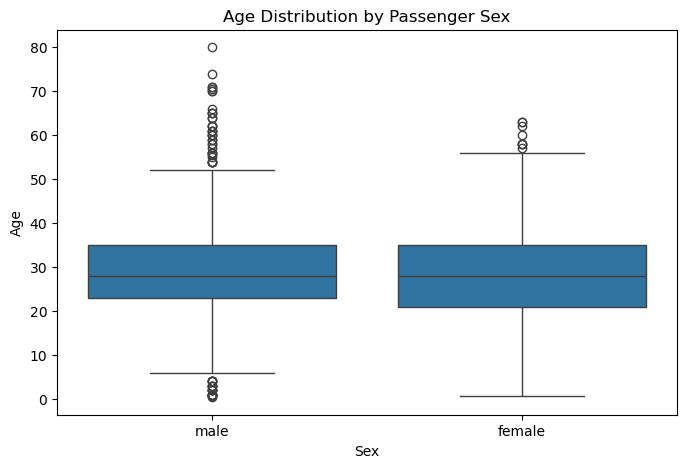

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Sex",
    y="Age"
)

plt.title("Age Distribution by Passenger Sex")
plt.xlabel("Sex")
plt.ylabel("Age")

plt.show()

## 7. Chi-Square Test

The chi-square test is used to examine whether there is an association between two categorical variables.

In this analysis, we will examine the relationship between:

- **Sex** — male or female
- **Survived** — 0 means did not survive, 1 means survived

### Hypotheses

- **Null hypothesis (H₀):** Passenger sex and survival are independent.
- **Alternative hypothesis (H₁):** Passenger sex and survival are associated.

We will use a significance level of 0.05.

### Creating a Contingency Table

A contingency table shows the number of observations for each combination of the two categorical variables.

In [14]:
contingency_table = pd.crosstab(
    df["Sex"],
    df["Survived"]
)

print("Contingency table:")
print(contingency_table)

Contingency table:
Survived    0    1
Sex               
female     81  233
male      468  109


### Performing the Chi-Square Test

In [15]:
chi2_statistic, chi2_p_value, degrees_of_freedom, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", round(chi2_statistic, 4))
print("P-value:", round(chi2_p_value, 6))
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 260.717
P-value: 0.0
Degrees of freedom: 1


### Decision and Interpretation

In [16]:
alpha = 0.05

if chi2_p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("There is statistically significant evidence of an association between passenger sex and survival.")
else:
    print("Decision: Do not reject the null hypothesis.")
    print("There is not enough statistical evidence to conclude that passenger sex and survival are associated.")

Decision: Reject the null hypothesis.
There is statistically significant evidence of an association between passenger sex and survival.


### Visualizing Survival by Sex

A bar chart can help us understand the difference in survival percentages between male and female passengers.

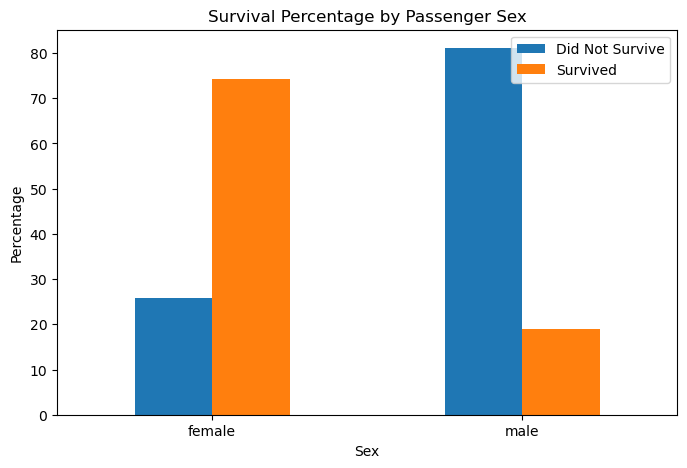

In [17]:
survival_by_sex = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

survival_by_sex.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Survival Percentage by Passenger Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Did Not Survive", "Survived"])

plt.show()

## 8. Overall Findings and Conclusion

In this notebook, statistical inference and hypothesis testing were applied to the cleaned Titanic dataset.

The main analyses included:

1. A 95% confidence interval for the average passenger age.
2. An independent samples t-test comparing the mean age of male and female passengers.
3. A chi-square test examining the relationship between passenger sex and survival.
4. A simple A/B testing example to understand how two groups can be compared statistically.

### Key Findings

- The confidence interval provided a range of plausible values for the population mean age based on the sample.
- The t-test was used to determine whether the average age differed between male and female passengers.
- The chi-square test was used to examine whether passenger sex and survival were associated.
- The p-value was used as evidence for deciding whether to reject the null hypothesis at the 0.05 significance level.

### Plain-Language Explanation

Statistical hypothesis testing helps us determine whether an observed difference or relationship in a sample provides enough evidence to draw a statistical conclusion.

A small p-value, below 0.05 in this notebook, provides evidence against the null hypothesis. A p-value equal to or greater than 0.05 means that there is not enough statistical evidence to reject the null hypothesis.

It is important to remember that statistical significance does not necessarily mean that a result is large or practically important. The results should always be interpreted in the context of the data and the research question.

### adding one final summary cell so your notebook clearly shows the tests performed.

In [18]:
print("Statistical Inference Summary")
print("-" * 35)

print("1. Confidence interval:")
print("   95% confidence interval calculated for passenger age.")

print("\n2. Independent samples t-test:")
print("   Compared mean age between male and female passengers.")
print("   P-value:", round(p_value, 6))

print("\n3. Chi-square test:")
print("   Examined the association between sex and survival.")
print("   P-value:", round(chi2_p_value, 6))

print("\n4. Significance level:")
print("   Alpha =", alpha)

Statistical Inference Summary
-----------------------------------
1. Confidence interval:
   95% confidence interval calculated for passenger age.

2. Independent samples t-test:
   Compared mean age between male and female passengers.
   P-value: 0.015013

3. Chi-square test:
   Examined the association between sex and survival.
   P-value: 0.0

4. Significance level:
   Alpha = 0.05


## 9. Final Conclusion

This analysis introduced the basic concepts of statistical inference, confidence intervals, p-values, hypothesis testing, and A/B testing.

The Titanic dataset was used to apply an independent samples t-test and a chi-square test. These tests demonstrated how statistical methods can be used to investigate differences between groups and relationships between categorical variables.

The analysis also showed the importance of interpreting statistical results carefully. A hypothesis test provides statistical evidence based on the sample and the assumptions of the test; it does not prove a hypothesis with absolute certainty.

Overall, this exercise provided practical experience in applying statistical inference and explaining hypothesis-testing results in plain language.

## 10. Completion Checklist

-  Loaded the cleaned Titanic dataset from Week 5
-  Reviewed the dataset structure and quality
-  Learned about statistical inference
-  Explained confidence intervals and margin of error
-  Calculated a 95% confidence interval
-  Explained p-values and hypothesis testing
-  Practiced a simple A/B testing example
-  Applied an independent samples t-test
-  Visualized the t-test groups with a box plot
-  Applied a chi-square test
-  Visualized survival percentages by sex
-  Interpreted statistical results in plain language
-  Added a final conclusion